# Day 3 — Performance Analytics
Returns, CAGR, Sharpe/Sortino, Alpha/Beta, Max Drawdown, Fund Scorecard, and Benchmark Comparison for all 40 schemes.


In [21]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DIR = Path("data/processed")
REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)

RF_ANNUAL = 0.065          # RBI repo rate proxy
TRADING_DAYS = 252


## 1. Load data


In [22]:
nav = pd.read_csv(PROCESSED_DIR / "02_nav_history.csv", parse_dates=["date"])
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master.csv")
benchmarks = pd.read_csv(PROCESSED_DIR / "10_benchmark_indices.csv", parse_dates=["date"])

print("NAV shape:", nav.shape)
print("Fund master shape:", fund_master.shape)
print("Benchmark indices available:", benchmarks["index_name"].unique())

# Pivot NAV to wide: rows = date, columns = amfi_code
nav_wide = nav.pivot(index="date", columns="amfi_code", values="nav").sort_index()
nav_wide.shape


NAV shape: (64320, 3)
Fund master shape: (40, 15)
Benchmark indices available: <ArrowStringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


(1608, 40)

## 2. Daily returns
`daily_return = nav_t / nav_t-1 - 1` for all 40 schemes. Validate the distribution looks reasonable (no extreme outliers from bad data).


count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
dtype: float64
Skew: 0.11226809083886621  Kurtosis: 3.1017517083576776

Suspicious daily moves (>20% in a day): 0


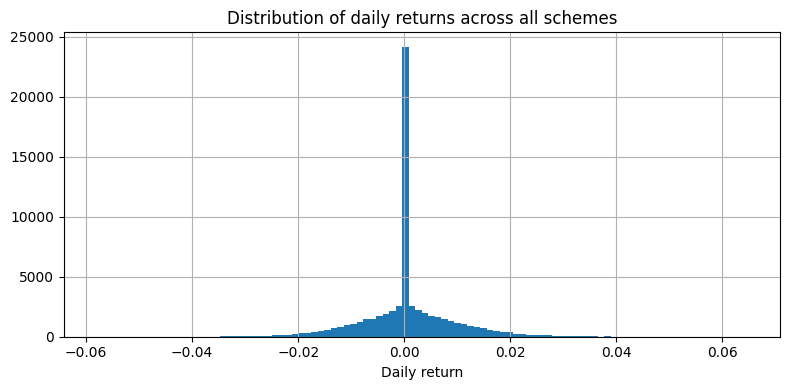

In [23]:
daily_returns = nav_wide.pct_change().dropna(how="all")

# Sanity check: describe the pooled distribution of daily returns across all funds
pooled = daily_returns.stack()
print(pooled.describe())
print("Skew:", pooled.skew(), " Kurtosis:", pooled.kurt())

# Flag any daily return magnitude > 20% as suspicious (mutual funds shouldn't move like this in a day)
suspicious = (daily_returns.abs() > 0.20)
n_suspicious = suspicious.sum().sum()
print(f"\nSuspicious daily moves (>20% in a day): {n_suspicious}")

fig, ax = plt.subplots(figsize=(8, 4))
pooled.hist(bins=100, ax=ax)
ax.set_title("Distribution of daily returns across all schemes")
ax.set_xlabel("Daily return")
plt.tight_layout()
plt.show()


## 3. CAGR — 1yr, 3yr, 5yr
`CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`. Comparison table across all funds.


In [24]:
def cagr(nav_series: pd.Series, years: float) -> float:
    nav_series = nav_series.dropna()
    if nav_series.empty:
        return np.nan
    end_date = nav_series.index.max()
    start_target = end_date - pd.DateOffset(years=years)
    # nearest available date on/after the target start date
    valid_starts = nav_series.index[nav_series.index <= start_target]
    if valid_starts.empty:
        return np.nan  # not enough history
    start_date = valid_starts.max()
    nav_start = nav_series.loc[start_date]
    nav_end = nav_series.loc[end_date]
    n_years = (end_date - start_date).days / 365.25
    if n_years <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_table = pd.DataFrame({
    "cagr_1yr": {code_: cagr(nav_wide[code_], 1) for code_ in nav_wide.columns},
    "cagr_3yr": {code_: cagr(nav_wide[code_], 3) for code_ in nav_wide.columns},
    "cagr_5yr": {code_: cagr(nav_wide[code_], 5) for code_ in nav_wide.columns},
})
cagr_table.index.name = "amfi_code"
cagr_table = cagr_table.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]],
                               left_index=True, right_on="amfi_code")
cagr_table.sort_values("cagr_3yr", ascending=False)


,cagr_1yr,cagr_3yr,cagr_5yr,amfi_code,scheme_name,fund_house
26,0.222779,0.351025,NaN,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
34,0.203760,0.339920,NaN,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
11,0.130738,0.324789,NaN,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
7,0.532772,0.324340,NaN,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
12,0.296277,0.317692,NaN,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
0,0.604893,0.304486,NaN,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
22,0.266776,0.295751,NaN,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
36,0.397838,0.291714,NaN,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
28,0.479638,0.289602,NaN,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
39,0.651955,0.269935,NaN,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund


## 4. Sharpe Ratio
`Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)`, Rf = 6.5% annual (RBI repo rate proxy). Ranked across all 40 funds.


In [25]:
rf_daily = RF_ANNUAL / TRADING_DAYS

mean_daily_return = daily_returns.mean()
std_daily_return = daily_returns.std()

sharpe = (mean_daily_return - rf_daily) / std_daily_return * np.sqrt(TRADING_DAYS)
sharpe = sharpe.rename("sharpe_ratio").sort_values(ascending=False)
sharpe_rank = sharpe.rank(ascending=False, method="min").rename("sharpe_rank")
sharpe.to_frame().join(sharpe_rank)


,sharpe_ratio,sharpe_rank
amfi_code,,
148567,1.068224,1.0
120843,0.965561,2.0
148569,0.919047,3.0
120505,0.883256,4.0
119551,0.860977,5.0
149323,0.832885,6.0
100033,0.808268,7.0
118632,0.758851,8.0
119094,0.730547,9.0


## 5. Sortino Ratio
Same formula, but the denominator uses only downside standard deviation (negative-return days only).


In [26]:
def downside_std(returns: pd.Series) -> float:
    downside = returns[returns < 0]
    if downside.empty:
        return np.nan
    return downside.std()

downside_std_series = daily_returns.apply(downside_std)
sortino = (mean_daily_return - rf_daily) / downside_std_series * np.sqrt(TRADING_DAYS)
sortino = sortino.rename("sortino_ratio").sort_values(ascending=False)
sortino.to_frame()


,sortino_ratio
amfi_code,
148567,1.490739
120843,1.479503
148569,1.352815
119551,1.291483
120505,1.285843
149323,1.167793
100033,1.144216
118632,1.098880
119598,1.067256


## 6. Alpha and Beta
OLS regression of each fund's daily returns on Nifty 100 daily returns using `scipy.stats.linregress`. `Alpha = intercept * 252`.


In [27]:
# Build benchmark daily return series
bench_wide = benchmarks.pivot(index="date", columns="index_name", values="close_value").sort_index()
bench_returns = bench_wide.pct_change().dropna(how="all")

if "NIFTY100" not in bench_returns.columns:
    print("WARNING: 'NIFTY100' not found in benchmark_indices.csv. Available:",
          bench_returns.columns.tolist())
    print("Falling back to NIFTY50 for the regression below — swap in NIFTY100 once available.")
    bench_col = "NIFTY50" if "NIFTY50" in bench_returns.columns else bench_returns.columns[0]
else:
    bench_col = "NIFTY100"

nifty_returns = bench_returns[bench_col]

alpha_beta_rows = []
for code_ in daily_returns.columns:
    fund_ret = daily_returns[code_]
    aligned = pd.concat([fund_ret, nifty_returns], axis=1, join="inner").dropna()
    if len(aligned) < 30:
        alpha_beta_rows.append({"amfi_code": code_, "alpha": np.nan, "beta": np.nan,
                                 "r_value": np.nan, "p_value": np.nan})
        continue
    x = aligned[bench_col].values
    y = aligned.iloc[:, 0].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    alpha_beta_rows.append({
        "amfi_code": code_,
        "alpha": intercept * TRADING_DAYS,
        "beta": slope,
        "r_value": r_value,
        "p_value": p_value,
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows).set_index("amfi_code")
alpha_beta_df = alpha_beta_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]],
                                     left_index=True, right_on="amfi_code")
alpha_beta_df.to_csv(REPORTS_DIR / "alpha_beta.csv", index=False)
alpha_beta_df.sort_values("alpha", ascending=False)


,alpha,beta,r_value,p_value,amfi_code,scheme_name,fund_house
2,0.303370,-0.023196,-0.011892,0.687179,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,0.300579,0.011455,0.005944,0.840494,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
12,0.292636,0.000549,0.000367,0.990090,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
36,0.282704,0.018134,0.013225,0.654295,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
22,0.273305,-0.022830,-0.018522,0.530528,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
7,0.271954,0.005104,0.003474,0.906369,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
34,0.269838,0.023684,0.021507,0.466427,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
38,0.265986,-0.002523,-0.001832,0.950525,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
26,0.260767,-0.066265,-0.044010,0.135988,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
0,0.232010,-0.031751,-0.029782,0.313143,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


## 7. Maximum Drawdown
`min(NAV / running_max - 1)` for each fund. Also finds the worst drawdown date range (peak date → trough date).


In [28]:
def max_drawdown_with_dates(nav_series: pd.Series):
    nav_series = nav_series.dropna()
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    trough_date = drawdown.idxmin()
    max_dd = drawdown.loc[trough_date]
    peak_date = nav_series.loc[:trough_date].idxmax()
    return max_dd, peak_date, trough_date

dd_rows = []
for code_ in nav_wide.columns:
    max_dd, peak_date, trough_date = max_drawdown_with_dates(nav_wide[code_])
    dd_rows.append({
        "amfi_code": code_,
        "max_drawdown_pct": max_dd * 100,
        "peak_date": peak_date,
        "trough_date": trough_date,
    })

drawdown_df = pd.DataFrame(dd_rows).set_index("amfi_code")
drawdown_df.sort_values("max_drawdown_pct")


,max_drawdown_pct,peak_date,trough_date
amfi_code,,,
119599,-52.574221,2023-01-17,2025-10-28
119095,-51.677754,2025-05-22,2026-05-11
101207,-35.446916,2024-11-21,2026-05-11
149324,-31.171900,2024-05-03,2025-01-03
119598,-28.706006,2024-08-28,2025-05-14
102886,-28.001124,2025-01-07,2026-04-27
100016,-24.734441,2022-03-30,2022-09-15
120842,-24.003511,2023-11-09,2024-10-17
118634,-23.344886,2025-04-09,2026-02-20


## 8. Fund Scorecard (0–100)
Composite: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank (inverse) + 10% × max DD rank (inverse).


In [29]:
def percentile_rank(series: pd.Series, ascending_is_better: bool = True) -> pd.Series:
    """0-100 percentile rank; higher score = better, regardless of raw direction."""
    s = series.copy()
    if not ascending_is_better:
        s = -s
    return s.rank(pct=True) * 100

scorecard = pd.DataFrame(index=fund_master["amfi_code"])
scorecard = scorecard.join(cagr_table.set_index("amfi_code")["cagr_3yr"])
scorecard = scorecard.join(sharpe)
scorecard = scorecard.join(alpha_beta_df.set_index("amfi_code")["alpha"])
scorecard = scorecard.join(fund_master.set_index("amfi_code")["expense_ratio_pct"])
scorecard = scorecard.join(drawdown_df["max_drawdown_pct"])

scorecard["rank_3yr"] = percentile_rank(scorecard["cagr_3yr"], ascending_is_better=True)
scorecard["rank_sharpe"] = percentile_rank(scorecard["sharpe_ratio"], ascending_is_better=True)
scorecard["rank_alpha"] = percentile_rank(scorecard["alpha"], ascending_is_better=True)
# lower expense ratio is better -> ascending_is_better=False inverts it
scorecard["rank_expense_inv"] = percentile_rank(scorecard["expense_ratio_pct"], ascending_is_better=False)
# max_drawdown_pct is negative; closer to 0 (less negative) is better -> ascending_is_better=True
scorecard["rank_maxdd_inv"] = percentile_rank(scorecard["max_drawdown_pct"], ascending_is_better=True)

scorecard["fund_score"] = (
    0.30 * scorecard["rank_3yr"]
    + 0.25 * scorecard["rank_sharpe"]
    + 0.20 * scorecard["rank_alpha"]
    + 0.15 * scorecard["rank_expense_inv"]
    + 0.10 * scorecard["rank_maxdd_inv"]
)

scorecard = scorecard.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]],
                             left_index=True, right_on="amfi_code")
scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard.to_csv(REPORTS_DIR / "fund_scorecard.csv", index=False)
scorecard.head(10)


,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,rank_3yr,rank_sharpe,rank_alpha,rank_expense_inv,rank_maxdd_inv,fund_score,amfi_code,scheme_name,fund_house
0,0.339920,1.068224,0.269838,1.46,-11.265729,97.5,100.0,85.0,45.00,82.5,86.2500,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,0.317692,0.883256,0.292636,1.36,-18.188514,90.0,92.5,95.0,65.00,40.0,82.8750,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
2,0.295751,0.965561,0.273305,1.45,-12.973968,85.0,97.5,90.0,47.50,70.0,82.0000,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
3,0.324340,0.808268,0.271954,1.38,-16.217209,92.5,85.0,87.5,60.00,52.5,80.7500,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
4,0.324789,0.714682,0.211948,0.80,-12.588276,95.0,75.0,70.0,72.50,72.5,79.3750,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
5,0.351025,0.730547,0.260767,1.38,-20.960884,100.0,80.0,80.0,60.00,32.5,78.2500,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
6,0.304486,0.860977,0.232010,1.54,-15.012385,87.5,90.0,77.5,26.25,60.0,74.1875,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
7,0.291714,0.919047,0.282704,1.60,-16.396743,82.5,95.0,92.5,11.25,50.0,73.6875,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
8,0.266631,0.711690,0.303370,1.43,-28.706006,72.5,70.0,100.0,50.00,12.5,68.0000,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
9,0.289602,0.717409,0.213998,1.60,-11.291596,80.0,77.5,72.5,11.25,80.0,67.5625,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


## 9. Benchmark Comparison Chart
Top 5 funds (by scorecard) vs Nifty 50 and Nifty 100 over 3 years. Tracking error = `std(fund_return - benchmark_return) * sqrt(252)`.


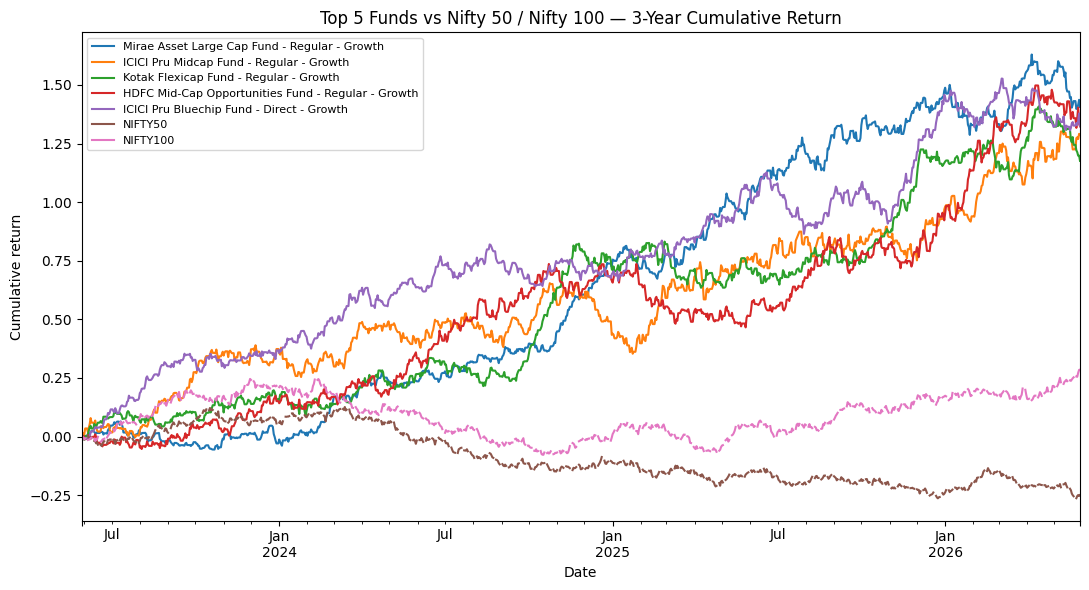

,amfi_code,scheme_name,tracking_error_vs_NIFTY50,tracking_error_vs_NIFTY100
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.191817,0.187867
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.228311,0.232515
2,120843,Kotak Flexicap Fund - Regular - Growth,0.204946,0.206410
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228081,0.224838
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.188360,0.187312


In [30]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()

end_date = nav_wide.index.max()
start_date = end_date - pd.DateOffset(years=3)

cum_returns = pd.DataFrame(index=nav_wide.loc[start_date:end_date].index)
for code_ in top5_codes:
    series = nav_wide.loc[start_date:end_date, code_].dropna()
    name = fund_master.loc[fund_master["amfi_code"] == code_, "scheme_name"].values[0]
    cum_returns[name] = series / series.iloc[0] - 1

for bench_name in [c for c in ["NIFTY50", "NIFTY100"] if c in bench_wide.columns]:
    series = bench_wide.loc[start_date:end_date, bench_name].dropna()
    cum_returns[bench_name] = series / series.iloc[0] - 1

fig, ax = plt.subplots(figsize=(11, 6))
cum_returns.plot(ax=ax)
ax.set_title("Top 5 Funds vs Nifty 50 / Nifty 100 — 3-Year Cumulative Return")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "benchmark_comparison.png", dpi=150)
plt.show()

# Tracking error per top-5 fund vs each available benchmark
tracking_error_rows = []
for code_ in top5_codes:
    fund_ret = daily_returns.loc[start_date:end_date, code_]
    name = fund_master.loc[fund_master["amfi_code"] == code_, "scheme_name"].values[0]
    row = {"amfi_code": code_, "scheme_name": name}
    for bench_name in [c for c in ["NIFTY50", "NIFTY100"] if c in bench_returns.columns]:
        bench_ret = bench_returns.loc[start_date:end_date, bench_name]
        aligned = pd.concat([fund_ret, bench_ret], axis=1, join="inner").dropna()
        te = (aligned.iloc[:, 0] - aligned.iloc[:, 1]).std() * np.sqrt(TRADING_DAYS)
        row[f"tracking_error_vs_{bench_name}"] = te
    tracking_error_rows.append(row)

tracking_error_df = pd.DataFrame(tracking_error_rows)
tracking_error_df
